In [1]:

# import library
from google.colab import files
uploaded = files.upload()
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Saving Features data set.csv to Features data set.csv
Saving sales data-set.csv to sales data-set.csv
Saving stores data-set.csv to stores data-set.csv


#introduction:

This project analyzes data to understand key factors influencing revenue. The analysis combines multiple datasets including sales, store information, and external features such as temperature, fuel price, and unemployment.

In [2]:

# load the data set
sales_data = pd.read_csv("sales data-set.csv")
features = pd.read_csv("Features data set.csv")
store = pd.read_csv("stores data-set.csv")

#Data preparation:

The datasets were first cleaned individually to ensure consistency. Missing values in MarkDown columns were replaced with 0, as they represent weeks with no promotions. Missing values in CPI and Unemployment were filled using mean values. The datasets were then merged using common columns such as Store and Date to create a unified dataset for analysis.

In [3]:

# checking for missing values in sales data-set.csv
sales_data.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0


In [4]:

#checking the missing value in features data-set.csv
features.isnull().sum()

,0
Store,0
Date,0
Temperature,0
Fuel_Price,0
MarkDown1,4158
MarkDown2,5269
MarkDown3,4577
MarkDown4,4726
MarkDown5,4140
CPI,585


In [5]:
# fill missing value in markdown colums with 0 to aoid losing huge data set and ensure good analysis
cols = ["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]
features[cols] = features[cols].fillna(0)

#fill null values in CPI an Unemployment column with their mean values
features["CPI"].fillna(features["CPI"].mean(), inplace=True)
features["Unemployment"].fillna(features["Unemployment"].mean(), inplace=True)

/tmp/ipykernel_311/2733193788.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  features["CPI"].fillna(features["CPI"].mean(), inplace=True)
/tmp/ipykernel_311/2733193788.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [6]:

#cross check the missing valus
features.isnull().sum()

,0
Store,0
Date,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0
MarkDown4,0
MarkDown5,0
CPI,0


In [7]:

# checking missing values in stores data-set.csv
store.isnull().sum()

,0
Store,0
Type,0
Size,0


In [8]:
#merge the data set
data = pd.merge(sales_data, features, on=["Store","Date","IsHoliday"])
data = pd.merge(data, store, on="Store")

In [9]:

# final check for missing values
data.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0
MarkDown3,0


In [10]:

# get shape of data set
data.shape

(421570, 16)

In [11]:

# get the info of data, number of row and column
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     421570 non-null  float64
 8   MarkDown2     421570 non-null  float64
 9   MarkDown3     421570 non-null  float64
 10  MarkDown4     421570 non-null  float64
 11  MarkDown5     421570 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


In [12]:

# get the descriptive statistics info
data.describe

<bound method NDFrame.describe of         Store  Dept        Date  Weekly_Sales  IsHoliday  Temperature  \
0           1     1  05/02/2010      24924.50      False        42.31   
1           1     1  12/02/2010      46039.49       True        38.51   
2           1     1  19/02/2010      41595.55      False        39.93   
3           1     1  26/02/2010      19403.54      False        46.63   
4           1     1  05/03/2010      21827.90      False        46.50   
...       ...   ...         ...           ...        ...          ...   
421565     45    98  28/09/2012        508.37      False        64.88   
421566     45    98  05/10/2012        628.10      False        64.89   
421567     45    98  12/10/2012       1061.02      False        54.47   
421568     45    98  19/10/2012        760.01      False        56.47   
421569     45    98  26/10/2012       1076.80      False        58.85   

        Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5  \
0            2.572       0.00       0.00       0.00       0.00       0.00   
1            2.548       0.00       0.00       0.00       0.00       0.00   
2            2.514       0.00       0.00       0.00       0.00       0.00   
3            2.561       0.00       0.00       0.00       0.00       0.00   
4            2.625       0.00       0.00       0.00       0.00       0.00   
...            ...        ...        ...        ...        ...        ...   
421565       3.997    4556.61      20.64       1.50    1601.01    3288.25   
421566       3.985    5046.74       0.00      18.82    2253.43    2340.01   
421567       4.000    1956.28       0.00       7.89     599.32    3990.54   
421568       3.969    2004.02       0.00       3.18     437.73    1537.49   
421569       3.882    4018.91      58.08     100.00     211.94     858.33   

               CPI  Unemployment Type    Size  
0       211.096358         8.106    A  151315  
1       211.242170         8.106    A  151315  
2       211.289143         8.106    A  151315  
3       211.319643         8.106    A  151315  
4       211.350143         8.106    A  151315  
...            ...           ...  ...     ...  
421565  192.013558         8.684    B  118221  
421566  192.170412         8.667    B  118221  
421567  192.327265         8.667    B  118221  
421568  192.330854         8.667    B  118221  
421569  192.308899         8.667    B  118221  

[421570 rows x 16 columns]>

In [13]:
# checking the firstfew data
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,05/02/2010,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315
1,1,1,12/02/2010,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315
2,1,1,19/02/2010,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315
3,1,1,26/02/2010,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315
4,1,1,05/03/2010,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315


#Holiday and non holiday sales:

A comparison was made between holiday and non-holiday periods using bar plots.

In [14]:
# compare mean sales between holiday and non holiday
data.groupby("IsHoliday")["Weekly_Sales"].mean()

,Weekly_Sales
IsHoliday,
False,15901.445069
True,17035.823187


/tmp/ipykernel_311/3559090005.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="IsHoliday", y="Weekly_Sales", data=data, palette=["green", "orange"])


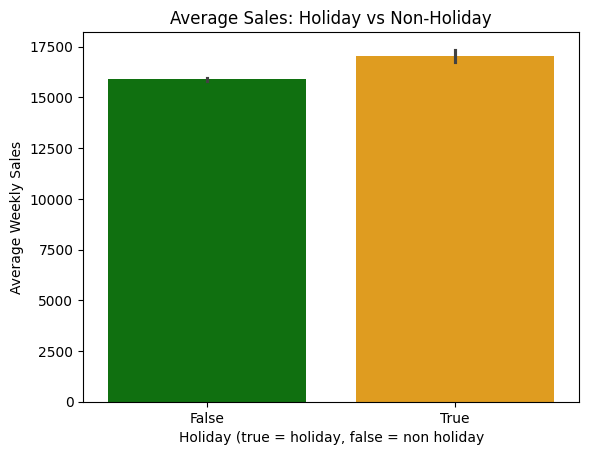

In [15]:


# visualization
sns.barplot(x="IsHoliday", y="Weekly_Sales", data=data, palette=["green", "orange"])
plt.title("Average Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday (true = holiday, false = non holiday")
plt.ylabel("Average Weekly Sales")

plt.show()

#Insight of above plot:

Holiday weeks tend to have higher average sales

Greater variability during holidays indicates spikes in demand

Confirms that holidays significantly impact revenue

In [16]:

# holiday sales by department
holiday_sales_dept = data[data["IsHoliday"] == True].groupby("Dept")["Weekly_Sales"].sum()

print(holiday_sales_dept)

Dept
1      8867168.77
2     18991468.92
3      5481134.64
4     12005820.97
5     14347362.90
         ...     
95    29996233.40
96     5723180.51
97     6133824.50
98     3191644.19
99      119272.58
Name: Weekly_Sales, Length: 81, dtype: float64


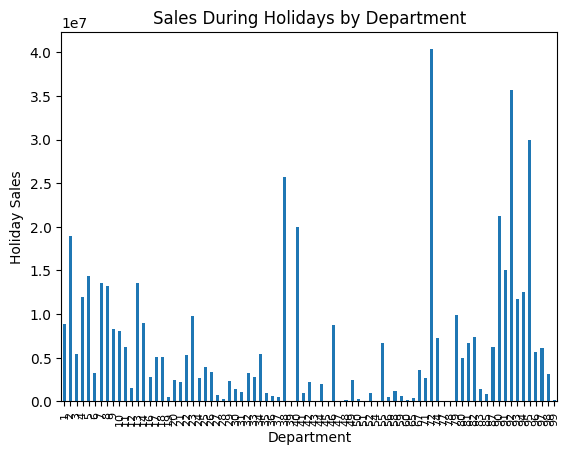

In [17]:

#Visualization
holiday_sales_dept.plot(kind="bar")
plt.xlabel("Department")
plt.ylabel("Holiday Sales")
plt.xticks(rotation='vertical', size=8)
plt.title("Sales During Holidays by Department")
plt.show()

#Holiday sales in each department:

The plot is created to compare holiday revenue in each department

#Insights:
-certain department produce high revenue during holiday weeks.
-High revenue indicate that the department has better location and demanded product

In [18]:

# top 10 department with high holiday sales
top_holiday_sales_by_dept=holiday_sales_dept.sort_values(ascending=False)

In [19]:
top_holiday_sales_by_dept

,Weekly_Sales
Dept,
72,40313605.46
92,35695397.10
95,29996233.40
38,25682245.57
90,21209128.22
...,...
51,1711.58
47,250.93
78,169.76


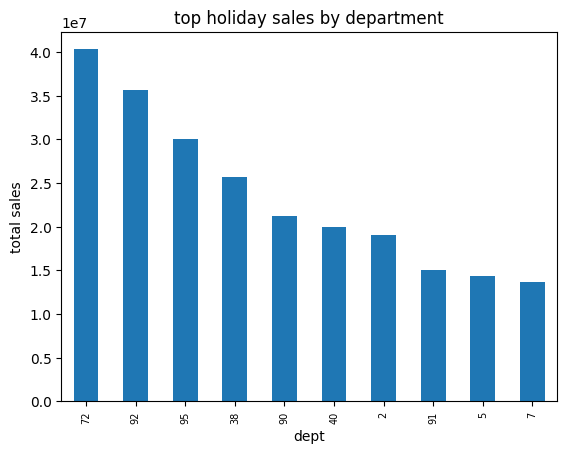

In [20]:
top_holiday_sales_by_dept.head(10).plot(kind="bar")
plt.xlabel('dept')
plt.ylabel('total sales')
plt.title('top holiday sales by department')
plt.xticks(rotation='vertical', size=7)
plt.show()

In [21]:

# convert the date inform of month_year
data["month_year"] = pd.to_datetime(data["Date"], format="%d/%m/%Y").dt.strftime("%y-%m")
data["month_year"]

,month_year
0,10-02
1,10-02
2,10-02
3,10-02
4,10-03
...,...
421565,12-09
421566,12-10
421567,12-10
421568,12-10


In [22]:

# the top month with the highest sales
data.groupby(["month_year"]).sum()["Weekly_Sales"].sort_values(ascending=False)

,Weekly_Sales
month_year,
10-12,2.887605e+08
11-12,2.880781e+08
12-06,2.406103e+08
12-08,2.368508e+08
10-07,2.325801e+08
12-03,2.315097e+08
10-04,2.314124e+08
11-07,2.299114e+08
11-04,2.265265e+08


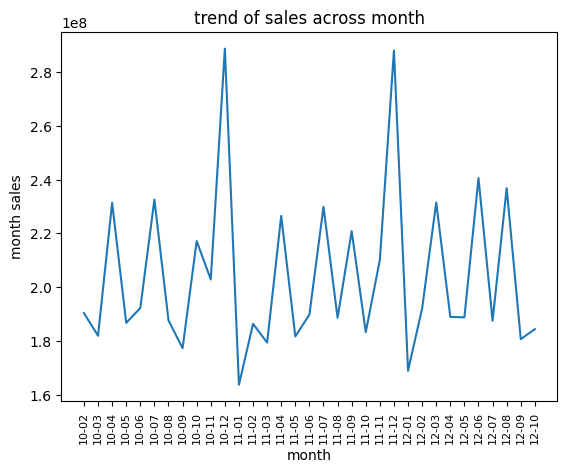

In [23]:

# the trend of sales
sales_trend = data.groupby(["month_year"]).sum()["Weekly_Sales"]
plt.plot(sales_trend.index, sales_trend.values)
plt.ylabel('month sales')
plt.xlabel('month')
plt.title('trend of sales across month')
plt.xticks(rotation='vertical', size=8)
plt.show()

#Sales trend over time:

A time-series analysis was performed to observe how sales change over time.

#Insight:

Sales show fluctuations across different periods

Peaks are observed during certain weeks, likely corresponding to holidays

Indicates seasonal patterns in customer purchasing behavior

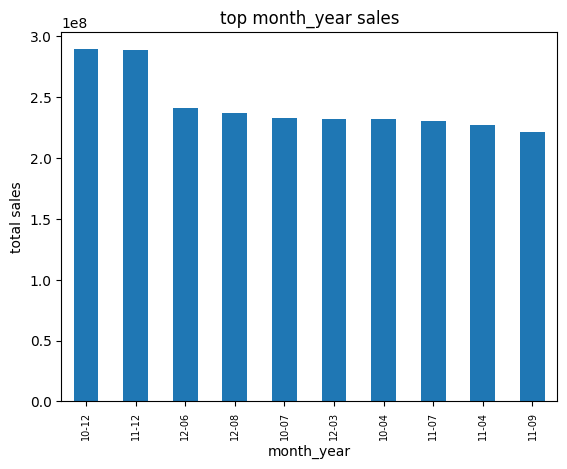

In [24]:

# the top 10 sales by month
sales_trend = data.groupby(["month_year"]).sum()["Weekly_Sales"].sort_values(ascending =False)
sales_trend.head(10).plot(kind="bar")
sales_trend.head(10).plot(kind="bar")
plt.xlabel('month_year')
plt.ylabel('total sales')
plt.title('top month_year sales')
plt.xticks(rotation='vertical', size=7)
plt.show()

In [26]:

#overall sales by department
mostsold_dept=data.groupby(["Dept"]).sum()["Weekly_Sales"].sort_values(ascending=False)
print(mostsold_dept)

Dept
92    4.839433e+08
95    4.493202e+08
38    3.931181e+08
72    3.057252e+08
90    2.910685e+08
          ...     
51    3.057283e+04
78    1.714710e+03
39    1.779800e+02
43    1.432000e+01
47   -4.962930e+03
Name: Weekly_Sales, Length: 81, dtype: float64


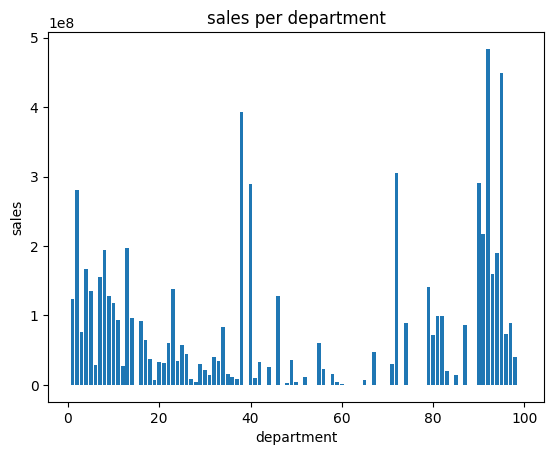

In [27]:
plt.bar(mostsold_dept.index, mostsold_dept.values)
plt.ylabel('sales')
plt.xlabel('department')
plt.title('sales per department')
plt.show()

The plot show that certain department contribute more revenue

In [28]:
data["Store"].max()

45

In [29]:
data["Store"].min()

1

In [30]:
data["Store"]

,Store
0,1
1,1
2,1
3,1
4,1
...,...
421565,45
421566,45
421567,45
421568,45


In [31]:
store_sales=data.groupby(["Store"]).sum()["Weekly_Sales"]
print(store_sales)

Store
1     2.224028e+08
2     2.753824e+08
3     5.758674e+07
4     2.995440e+08
5     4.547569e+07
6     2.237561e+08
7     8.159828e+07
8     1.299512e+08
9     7.778922e+07
10    2.716177e+08
11    1.939628e+08
12    1.442872e+08
13    2.865177e+08
14    2.889999e+08
15    8.913368e+07
16    7.425243e+07
17    1.277821e+08
18    1.551147e+08
19    2.066349e+08
20    3.013978e+08
21    1.081179e+08
22    1.470756e+08
23    1.987506e+08
24    1.940160e+08
25    1.010612e+08
26    1.434164e+08
27    2.538559e+08
28    1.892637e+08
29    7.714155e+07
30    6.271689e+07
31    1.996139e+08
32    1.668192e+08
33    3.716022e+07
34    1.382498e+08
35    1.315207e+08
36    5.341221e+07
37    7.420274e+07
38    5.515963e+07
39    2.074455e+08
40    1.378703e+08
41    1.813419e+08
42    7.956575e+07
43    9.056544e+07
44    4.329309e+07
45    1.123953e+08
Name: Weekly_Sales, dtype: float64


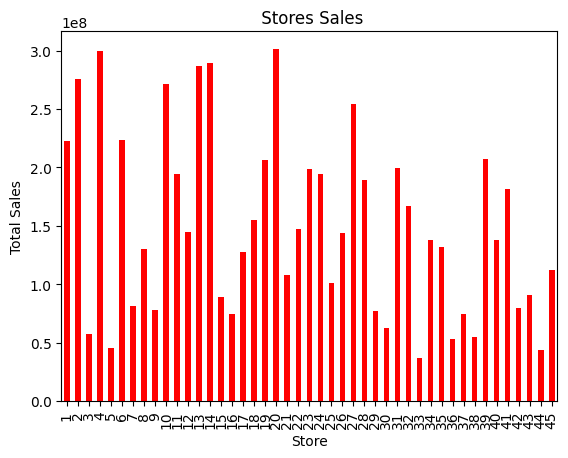

In [32]:

store_sales.plot(kind="bar", color ="red")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.title(" Stores Sales")
plt.show()

In [33]:

# top performing store by sales
top_store=data.groupby(["Store"]).sum()["Weekly_Sales"].sort_values(ascending=False)
print(top_store)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
19    2.066349e+08
31    1.996139e+08
23    1.987506e+08
24    1.940160e+08
11    1.939628e+08
28    1.892637e+08
41    1.813419e+08
32    1.668192e+08
18    1.551147e+08
22    1.470756e+08
12    1.442872e+08
26    1.434164e+08
34    1.382498e+08
40    1.378703e+08
35    1.315207e+08
8     1.299512e+08
17    1.277821e+08
45    1.123953e+08
21    1.081179e+08
25    1.010612e+08
43    9.056544e+07
15    8.913368e+07
7     8.159828e+07
42    7.956575e+07
9     7.778922e+07
29    7.714155e+07
16    7.425243e+07
37    7.420274e+07
30    6.271689e+07
3     5.758674e+07
38    5.515963e+07
36    5.341221e+07
5     4.547569e+07
44    4.329309e+07
33    3.716022e+07
Name: Weekly_Sales, dtype: float64


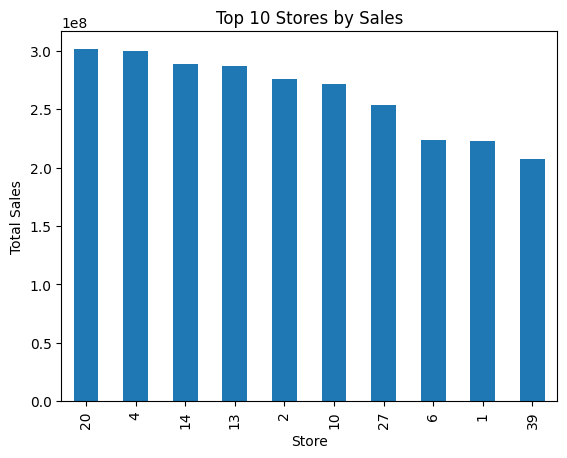

In [34]:
#visualization of the top 10
top_store.head(10).plot(kind="bar")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.title("Top 10 Stores by Sales")
plt.show()

In [35]:

#Store with high holiday sales
holiday_store_sales = data[data["IsHoliday"]==True].groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)

print(holiday_store_sales.sort_values(ascending=False))

Store
20    22490350.81
4     22431026.24
14    21205829.98
10    21137559.49
13    21130438.06
2     20792669.00
27    18922992.78
6     16809079.27
1     16657476.56
19    15770467.34
39    15511274.80
31    15000260.30
28    14782446.05
24    14750982.51
23    14625422.94
11    14483944.85
41    13349478.56
32    12037840.83
18    11694221.61
12    11381404.20
22    10848746.56
35    10743484.57
26    10720468.49
34    10419780.89
40    10080340.75
17     9797969.71
8      9753308.60
45     8362937.13
21     8264913.09
25     7396768.42
15     7064060.18
7      6724002.65
43     6359462.78
29     6069578.89
9      5889508.21
42     5676941.58
16     5667336.46
37     5075250.50
3      4378110.50
30     4368593.07
38     3815098.78
36     3676406.30
5      3595016.07
44     2960356.01
33     2625945.19
Name: Weekly_Sales, dtype: float64


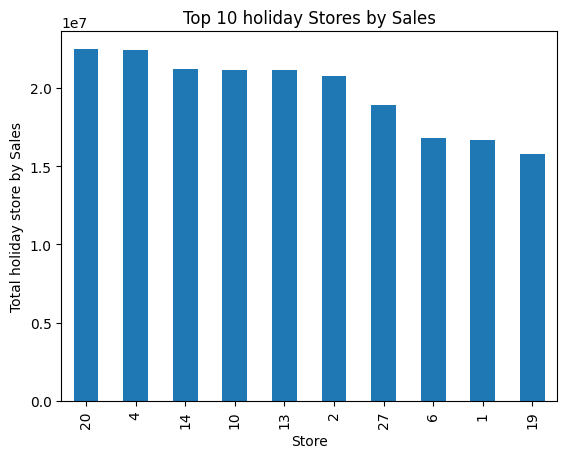

In [36]:
holiday_store_sales.head(10).plot(kind="bar")
plt.xlabel("Store")
plt.ylabel("Total holiday store by Sales")
plt.title("Top 10 holiday Stores by Sales")
plt.show()

#Top Performing Stores

Sales were grouped by store to identify the highest-performing locations.

#Insight:

Certain stores (e.g., Store 20) generate significantly higher revenue

Indicates variation in performance across locations

Suggests influence of store size, location, or customer demand

In [37]:

#monthly sales for each store
store_trend = data.groupby(["month_year","Store"])["Weekly_Sales"].sum()

print(store_trend)

month_year  Store
10-02       1        6307344.10
            2        8264347.77
            3        1711198.23
            4        8299040.36
            5        1202728.00
                        ...    
12-10       41       5452445.75
            42       2261705.49
            43       2473507.39
            44       1360020.41
            45       2946326.39
Name: Weekly_Sales, Length: 1485, dtype: float64


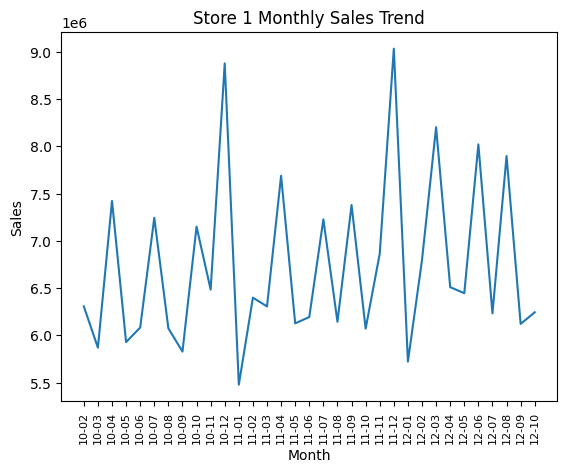

In [38]:

# trend in monthly sales in store 1
store1 = data[data["Store"] == 1].groupby("month_year")["Weekly_Sales"].sum()

plt.plot(store1.index, store1.values)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation='vertical', size=8)
plt.title("Store 1 Monthly Sales Trend")
plt.show()

In [39]:

# department in store 20 with hi revenue
store20 = data[data["Store"] == 20]
print(store20)

        Store  Dept        Date  Weekly_Sales  IsHoliday  Temperature  \
187335     20     1  05/02/2010      46021.21      False        25.92   
187336     20     1  12/02/2010      52734.17       True        22.12   
187337     20     1  19/02/2010      55649.79      False        25.43   
187338     20     1  26/02/2010      36805.42      False        32.32   
187339     20     1  05/03/2010      41206.78      False        31.75   
...       ...   ...         ...           ...        ...          ...   
197544     20    99  07/09/2012          0.67       True        76.36   
197545     20    99  14/09/2012          0.05      False        64.84   
197546     20    99  21/09/2012         29.91      False        60.94   
197547     20    99  05/10/2012        660.00      False        60.77   
197548     20    99  12/10/2012        200.00      False        47.20   

        Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5  \
187335       2.784       0.00       0.00      

In [40]:

#the department in store 20 wich have high revenue
dept_sales = store20.groupby("Dept")["Weekly_Sales"].sum().sort_values(ascending=False)
print(dept_sales)

Dept
92    23542625.04
95    21537795.62
38    15759345.93
90    13707777.99
72    13154550.44
         ...     
45         666.18
96         244.27
51         161.18
78          29.00
47        -378.58
Name: Weekly_Sales, Length: 78, dtype: float64


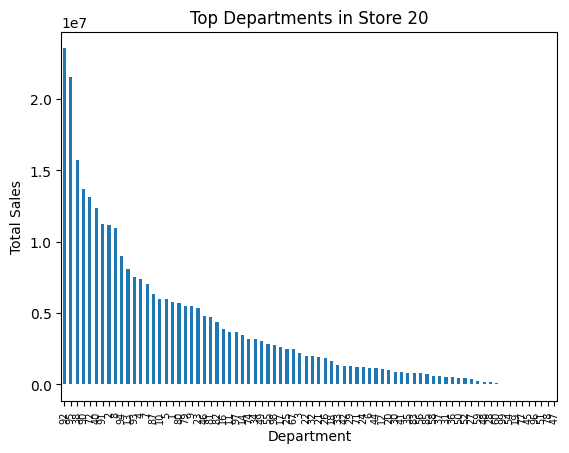

In [41]:

# department in store 20 wich generate high sales
dept_sales.plot(kind="bar")
plt.title("Top Departments in Store 20")
plt.xlabel("Department")
plt.ylabel("Total Sales")
plt.xticks(size=7)
plt.show()

<Axes: xlabel='Temperature', ylabel='Weekly_Sales'>

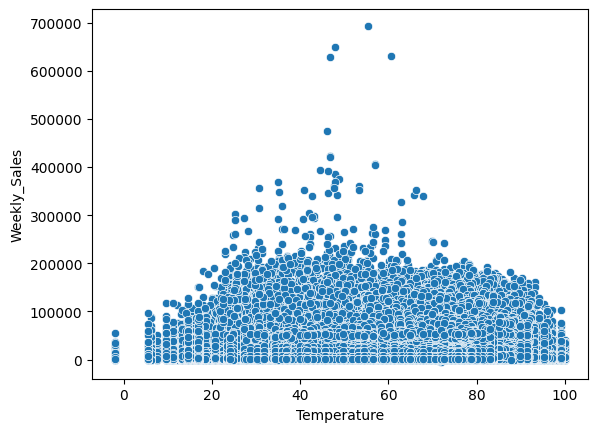

In [42]:

# sales trend by temperature
sns.scatterplot(x="Temperature", y="Weekly_Sales", data=data)

<Axes: xlabel='Fuel_Price', ylabel='Weekly_Sales'>

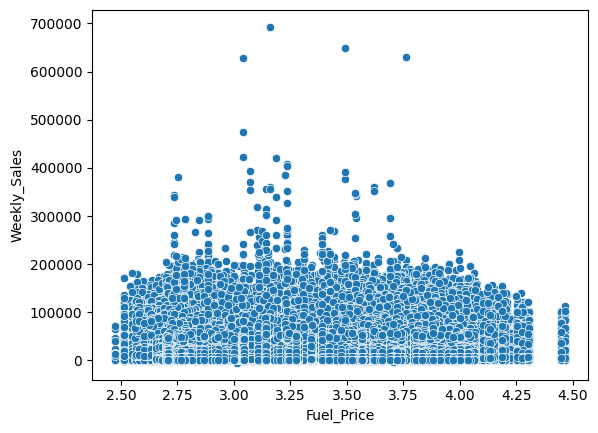

In [43]:

# trend of sales by fuel price
sns.scatterplot(x="Fuel_Price", y="Weekly_Sales", data=data)

#Fuel Price vs Sales:

A scatterplot was used to analyze the relationship between fuel price and weekly sales.

#Insight:

Data points are widely scattered with no clear pattern

Indicates a weak or no relationship

Suggests fuel price does not significantly affect sales

<Axes: xlabel='Unemployment', ylabel='Weekly_Sales'>

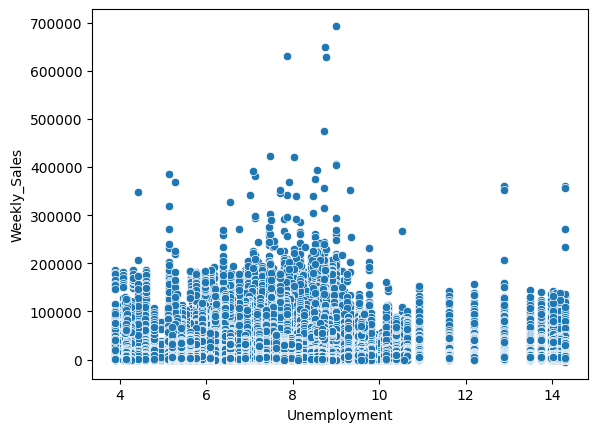

In [44]:

# impact of unemployment on sales
sns.scatterplot(x="Unemployment", y="Weekly_Sales", data=data)

#Unemployment vs Sales:

The relationship between unemployment rate and sales was examined.

#Insight:

Slight negative trend observed

Higher unemployment may slightly reduce sales

However, the relationship is weak and not a major driver

In [45]:

# sales performance by store type
store_type_performance=data.groupby("Type")["Weekly_Sales"].mean()
print (store_type_performance)

Type
A    20099.568043
B    12237.075977
C     9519.532538
Name: Weekly_Sales, dtype: float64


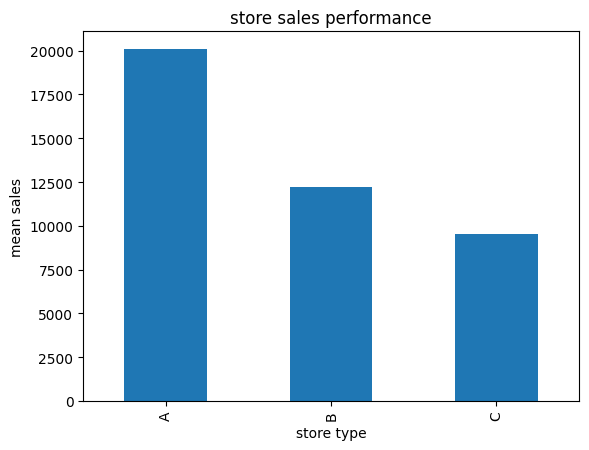

In [46]:
# visualize store type performance
store_type_performance.plot(kind="bar")
plt.xlabel('store type')
plt.ylabel('mean sales')
plt.title('store sales performance')
plt.show()

<Axes: xlabel='Size', ylabel='Weekly_Sales'>

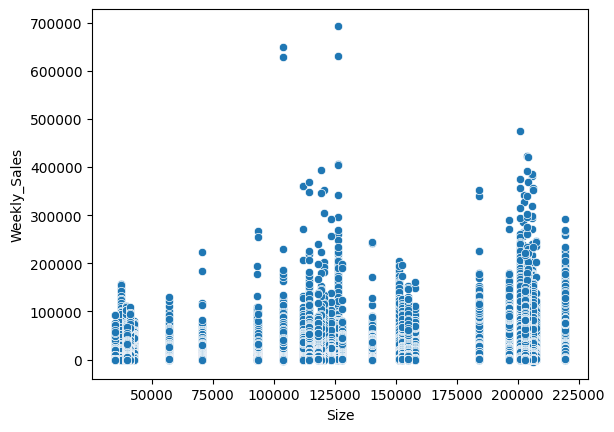

In [47]:

#sales by store size
sns.scatterplot(x="Size", y="Weekly_Sales", data=data)

#Store Size vs Sales:

A scatterplot was used to analyze the effect of store size on sales.

#Insight:

A slight positive relationship is observed

Larger stores tend to generate higher sales

However, variability suggests other factors also influence performance

<Axes: xlabel='Temperature', ylabel='Weekly_Sales'>

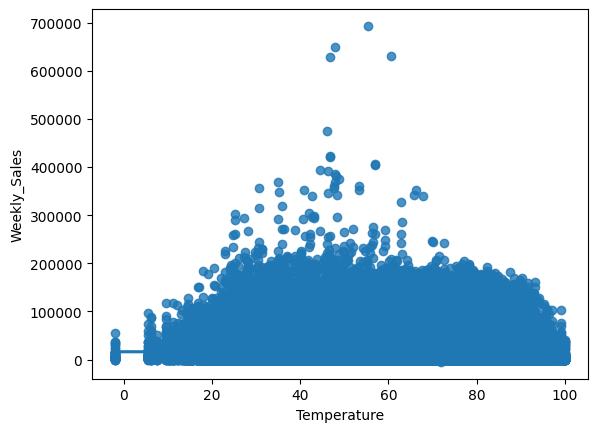

In [49]:


#clear view the plot to see how the dot are organized
sns.regplot(x="Temperature", y="Weekly_Sales", data=data)

<Axes: xlabel='Fuel_Price', ylabel='Weekly_Sales'>

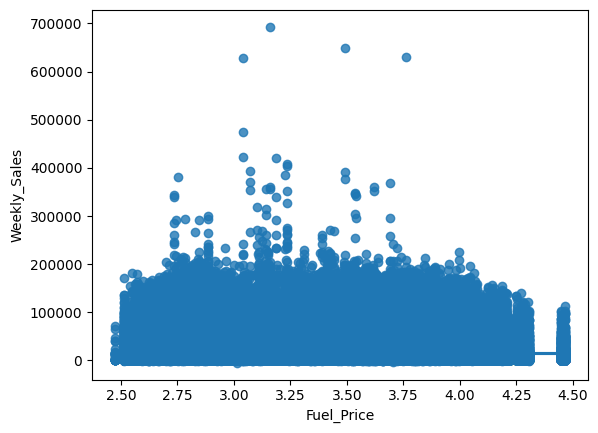

In [50]:
sns.regplot(x="Fuel_Price", y="Weekly_Sales", data=data)

<Axes: xlabel='Unemployment', ylabel='Weekly_Sales'>

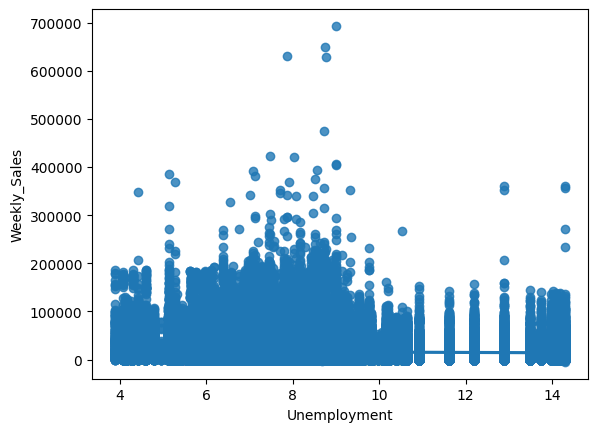

In [51]:
sns.regplot(x="Unemployment", y="Weekly_Sales", data=data)

<Axes: xlabel='Size', ylabel='Weekly_Sales'>

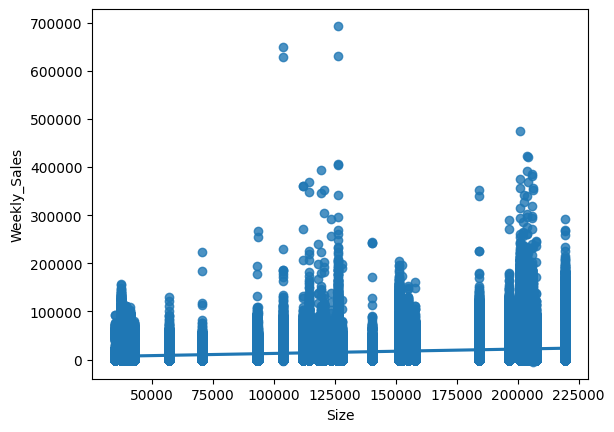

In [52]:
sns.regplot(x="Size", y="Weekly_Sales", data=data)

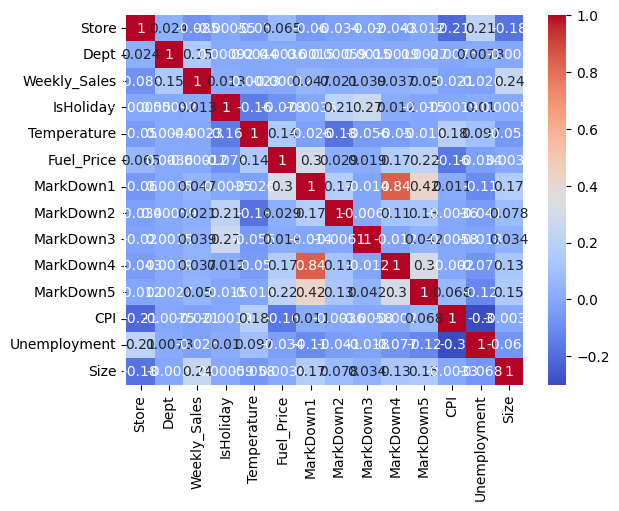

In [53]:

#relationsgip between weekly sales and other external factors
corr = data.corr(numeric_only=True )

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

The heatmap show that External economic and environmental factors have minimal impact on sales

In [54]:
# total promotion effect
data["Total_MarkDown"] = data[["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]].sum(axis=1)
data["Total_MarkDown"]

,Total_MarkDown
0,0.00
1,0.00
2,0.00
3,0.00
4,0.00
...,...
421565,9468.01
421566,9659.00
421567,6554.03
421568,3982.42


<Axes: xlabel='Total_MarkDown', ylabel='Weekly_Sales'>

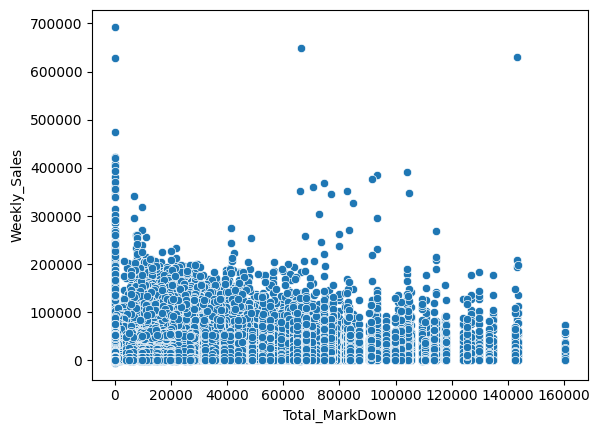

In [55]:
#relationship between promotion distribution and sales
sns.scatterplot(x="Total_MarkDown", y="Weekly_Sales", data=data)

#Promotions (MarkDown) Analysis:

Promotional data (MarkDown columns) were combined to evaluate their effect on sales.

#Insight:

Promotions show a positive relationship with sales

Stores with promotions tend to perform better

Indicates that discount strategies are effective in boosting revenue

<Axes: xlabel='Has_Promo', ylabel='Weekly_Sales'>

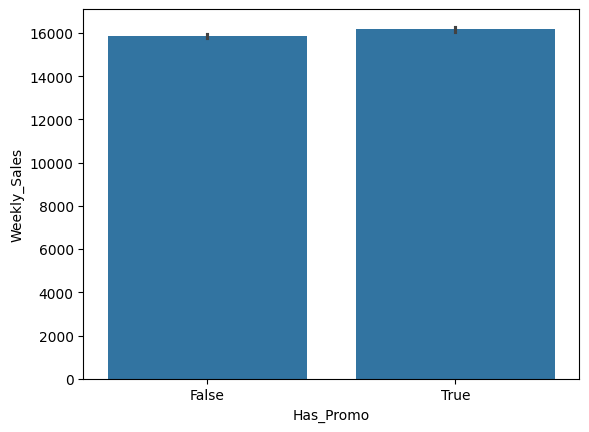

In [57]:
# store with promotions and stores with no promotions
data["Has_Promo"] = data["Total_MarkDown"] > 0

sns.barplot(x="Has_Promo", y="Weekly_Sales", data=data)

In [58]:
#correlation
data[["Weekly_Sales","Total_MarkDown"]].corr()

,Weekly_Sales,Total_MarkDown
Weekly_Sales,1.000000,0.065237
Total_MarkDown,0.065237,1.000000


#Conclusion:

This analysis demonstrates that internal business strategies such as promotions and holiday planning have a stronger impact on sales compared to external economic factors. Retailers can improve performance by focusing on promotional campaigns and optimizing store operations.